In [1]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from sklearn.linear_model import LinearRegression
import datetime
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

### Transformar o arquivo TXT em um parquet
Não tem função analítica, mas trás alguns benefícios:
- Maior performance para leitura 
- Maior compactação
> agora pode enviar esse arquivo para o github

In [2]:
try:
    df_household_convert = pd.read_csv(
        "data/household_power_consumption.txt",
        sep=";",
        dtype=str
    )

    df_household_convert.to_parquet('data/household_power_consumption.parquet', engine='fastparquet', index=False)
except FileNotFoundError:
    print("Arquivo de ref não existe")
except Exception as e:
    print(e)

Arquivo de ref não existe


### 1. Carregue o dataset e exiba as 10 primeiras linhas.

In [3]:
df_household = pd.read_parquet(
    "data/household_power_consumption.parquet",
    engine='fastparquet',
)

df_household.head(10)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.000
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.000
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.000
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.000
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.000
5,16/12/2006,17:29:00,3.520,0.522,235.020,15.000,0.000,2.000,17.000
6,16/12/2006,17:30:00,3.702,0.520,235.090,15.800,0.000,1.000,17.000
7,16/12/2006,17:31:00,3.700,0.520,235.220,15.800,0.000,1.000,17.000
8,16/12/2006,17:32:00,3.668,0.510,233.990,15.800,0.000,1.000,17.000
9,16/12/2006,17:33:00,3.662,0.510,233.860,15.800,0.000,2.000,16.000


---

### 2. Explique a diferença entre as variáveis Global_active_power e Global_reactive_power.

- Global_active_power:
  A energia real que está sendo consumida pela residência para realizar trabalho útil.

- Global_reactive_power:
  A energia que circula no sistema elétrico, mas não é convertida em trabalho útil.


---

### 3. Verifique se existem valores ausentes no dataset. Quantifique-os.

In [4]:
for col in [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
]:
    df_household[col] = pd.to_numeric(df_household[col], errors='coerce')

In [5]:
df_household.info()
df_household.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [6]:
df_null_data = pd.DataFrame(
    {
        "nao_nulos": df_household.notna().sum(),
        "nulos": df_household.isna().sum(),
        "percentual (%)": df_household.isna().mean() * 100,
    }
)
df_null_data

,nao_nulos,nulos,percentual (%)
Date,2075259,0,0.000000
Time,2075259,0,0.000000
Global_active_power,2049280,25979,1.251844
Global_reactive_power,2049280,25979,1.251844
Voltage,2049280,25979,1.251844
Global_intensity,2049280,25979,1.251844
Sub_metering_1,2049280,25979,1.251844
Sub_metering_2,2049280,25979,1.251844
Sub_metering_3,2049280,25979,1.251844


---

### 4. Converta a coluna Date para o tipo datetime e crie uma nova coluna com o dia da semana correspondente


In [7]:
def dia_da_semana(dia: pd.Timestamp):
    dia_semana = datetime.date.weekday(dia)
    if dia_semana == 0:
        return "Segunda"
    elif dia_semana == 1:
        return "Terça"
    elif dia_semana == 2:
        return "Quarta"
    elif dia_semana == 3:
        return "Quinta"
    elif dia_semana == 4:
        return "Sexta"
    elif dia_semana == 5:
        return "Sabado"
    elif dia_semana == 6:
        return "Domingo"
    else:
        return "erro"

In [8]:
df_household['Date'] = pd.to_datetime(df_household['Date'], dayfirst=True)
df_household['week_day'] = df_household['Date'].apply(lambda x: dia_da_semana(x))

In [9]:
df_household.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,week_day
0,2006-12-16,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,Sabado
1,2006-12-16,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,Sabado
2,2006-12-16,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,Sabado
3,2006-12-16,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,Sabado
4,2006-12-16,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,Sabado


---

### 5. Filtre os registros apenas do ano de 2007 e calcule a média de consumo diário de Global_active_power.


In [10]:
df_household['year'] = df_household['Date'].apply(lambda x: x.year)

In [11]:
df_household.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,week_day,year
0,2006-12-16,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,Sabado,2006
1,2006-12-16,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,Sabado,2006
2,2006-12-16,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,Sabado,2006
3,2006-12-16,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,Sabado,2006
4,2006-12-16,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,Sabado,2006


In [12]:
df_household_group_by_year = (
    df_household.groupby(["year"])
    .agg({"Global_active_power": "mean"})
    .reset_index()
)
df_household_group_by_year[df_household_group_by_year['year'] == 2007]
# df_household_group_by_year.info()

,year,Global_active_power
1,2007,1.117008


---

### 6. Gere um gráfico de linha mostrando a variação de Global_active_power em um único dia à sua escolha.


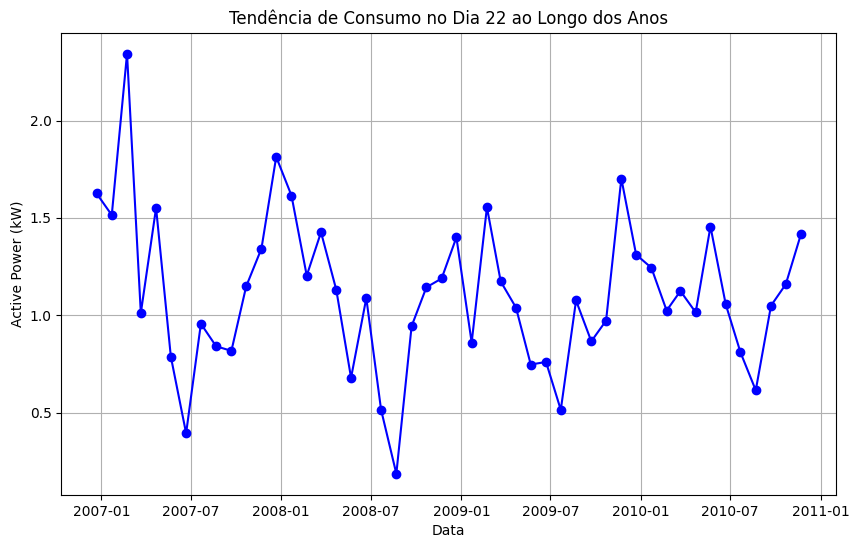

In [13]:
df_household_group_by_date = (
    df_household.groupby(["year", "Date"])
    .agg({"Global_active_power": "mean", "Voltage": "mean"})
    .reset_index()
)

df_household_group_by_date["day"] = df_household_group_by_date["Date"].apply(
    lambda x: x.day
)

# day_consumption = df_household_group_by_date[["year", "day", "Global_active_power"]]
day_consumption = df_household_group_by_date.copy()
day_consumption = day_consumption[day_consumption["day"] == 22]

# Plotar a tendência de consumo ao longo dos anos
plt.figure(figsize=(10, 6))
plt.plot(
    day_consumption["Date"],
    day_consumption["Global_active_power"],
    marker="o",
    linestyle="-",
    color="b",
)
plt.xlabel("Data")
plt.ylabel("Active Power (kW)")
plt.title("Tendência de Consumo no Dia 22 ao Longo dos Anos")
plt.grid(True)
plt.show()


---

### 7. Crie um histograma da variável Voltage. O que pode ser observado sobre sua distribuição?

In [14]:
mean_consuption = df_household_group_by_date[["Date", "Voltage"]]

fig = px.bar(
    mean_consuption,
    x="Date",
    y="Voltage",
    title="Voltagem / ano",
    text="Voltage",
)
fig.update_layout(
    width=800,
    height=800,
)

fig.show()

Pode-se identificar que a Voltagem é algo estável ao longo do tempo.

--- 

### 8. Calcule o consumo médio por mês em todo o período disponível no dataset.


In [15]:
month_consuption = df_household_group_by_date.copy()
month_consuption['month'] = month_consuption['Date'].apply(lambda x: x.month)
month_consuption_grouped = month_consuption.groupby("month")['Global_active_power'].mean().round(5).reset_index()

fig = px.bar(
    month_consuption_grouped,
    x="month",
    y="Global_active_power",
    title="Comsumo / mês",
    text="Global_active_power",
)
fig.update_layout(
    width=800,
    height=800,
)

fig.show()

Podemos notar que segundo e terceiro trimestre apresentam um consumo menor em relação ao primeiro e último.
levando em conta qeu foi agrupado por mês, e contendo mais de 1 ano, também temos o indicio de um padrão de consumo anual.

--- 

### 9. Identifique o dia com maior consumo de energia ativa global (Global_active_power).

In [16]:
max_consuption_day = df_household.copy()

max_value = max(max_consuption_day['Global_active_power'])

max_consuption_day = max_consuption_day[max_consuption_day['Global_active_power'] == max_value]

max_consuption_day

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,week_day,year
1150545,2009-02-22,17:09:00,11.122,0.174,229.78,48.4,35.0,69.0,16.0,Domingo,2009


--- 

### 10. Compare o consumo médio de energia ativa global em dias de semana versus finais desemana.

In [17]:
week_day_consuption = df_household.groupby('week_day')['Global_active_power'].mean().round(3).reset_index()

fig = px.bar(
    week_day_consuption,
    x="week_day",
    y="Global_active_power",
    title="Comsumo / dia da semana",
    text="Global_active_power",
)
fig.update_layout(
    width=800,
    height=800,
)

fig.show()

O consumo de energia é maior aos finais de semana

--- 

### 11. Calcule a correlação entre as variáveis Global_active_power, Global_reactive_power, Voltage e Global_intensity.

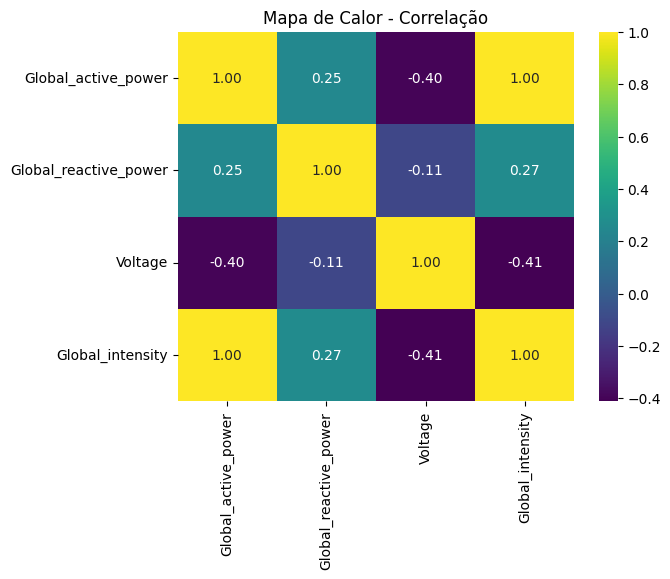

In [18]:

df_correlation = df_household[
    ["Global_active_power", "Global_reactive_power", "Voltage", "Global_intensity"]
].copy()

# Calcula a matriz de correlação
corr = df_correlation.corr()

# Cria o mapa de calor
sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis")

plt.title("Mapa de Calor - Correlação")
plt.show()

As variáveis não apresentam uma 'correlação' expressiva, contudo, a voltagem é quem tem maior relação. 

---

### 12. Crie uma nova variável chamada Total_Sub_metering que some Sub_metering_1,Sub_metering_2 e Sub_metering_3

In [19]:
'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'

def soma_sub_metering(row):
    soma = row['Sub_metering_1'] + row['Sub_metering_2'] + row['Sub_metering_3']
    return soma

df_household['Total_Sub_metering'] = df_household.apply(lambda x: soma_sub_metering(x), axis=1)
df_household.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,week_day,year,Total_Sub_metering
0,2006-12-16,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,Sabado,2006,18.0
1,2006-12-16,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,Sabado,2006,17.0
2,2006-12-16,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,Sabado,2006,19.0
3,2006-12-16,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,Sabado,2006,18.0
4,2006-12-16,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,Sabado,2006,18.0


--- 

### 13. Verifique se há algum mês em que Total_Sub_metering ultrapassa a média de Global_active_power.

In [20]:
df_household["simple_date"] = df_household["Date"].apply(lambda x: x.strftime("%Y-%b"))
df_household_group_by_simple_date = (
    df_household.groupby(["simple_date"])
    .agg({"Total_Sub_metering": "mean"})
    .reset_index()
)
global_consuption_mean = df_household["Global_active_power"].mean()
df_household_group_by_simple_date.head()

,simple_date,Total_Sub_metering
0,2006-Dec,10.873181
1,2007-Apr,6.839375
2,2007-Aug,6.979336
3,2007-Dec,11.636551
4,2007-Feb,9.486135


In [21]:
df_household_group_by_simple_date["dif_power_metering"] = (
    df_household_group_by_simple_date["Total_Sub_metering"].apply(
        lambda x: global_consuption_mean - x
    )
)
df_household_group_by_simple_date.head()

,simple_date,Total_Sub_metering,dif_power_metering
0,2006-Dec,10.873181,-9.781566
1,2007-Apr,6.839375,-5.747760
2,2007-Aug,6.979336,-5.887721
3,2007-Dec,11.636551,-10.544936
4,2007-Feb,9.486135,-8.394520


In [22]:
fig = px.bar(
    df_household_group_by_simple_date,
    x="simple_date",
    y="dif_power_metering",
    title="Comsumo / dia da semana",
    text="dif_power_metering",
)
fig.update_layout(
    width=800,
    height=800,
)

fig.show()

nenhum mês possui um Total_Sub_metering maior que a média de Global_active_power

--- 

### 14. Faça um gráfico de série temporal do Voltage para o ano de 2008.

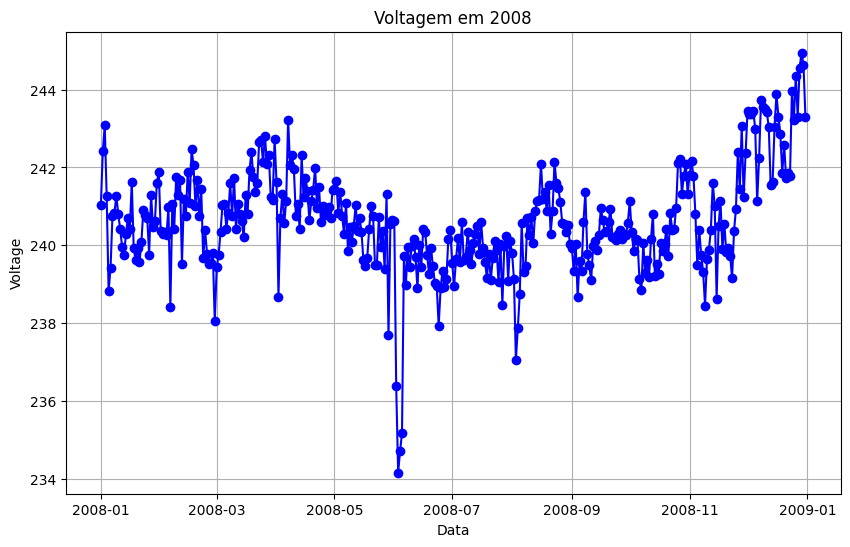

In [23]:
df_voltage_year = df_household[
    [
        "Date",
        "Voltage",
        "year",
    ]
].copy()

df_voltage_year = df_voltage_year[df_voltage_year['year'] == 2008]

df_voltage_year_grouped = df_voltage_year.groupby(['Date','year'])['Voltage'].mean().round(2).reset_index()

# Plotar a tendência de consumo ao longo dos anos
plt.figure(figsize=(10, 6))
plt.plot(
    df_voltage_year_grouped["Date"],
    df_voltage_year_grouped["Voltage"],
    marker="o",
    linestyle="-",
    color="b",
)
plt.xlabel("Data")
plt.ylabel("Voltage")
plt.title("Voltagem em 2008")
plt.grid(True)
plt.show()

Ao se acompanhar o ano de 2008 podemos confirmar o padrão mensal visto anteriormente.

Esses 4 pontos discrepantes no mes 06/2008, tem 2 possibilidades:
1. Registro incorreto
2. Uma queda de energia que durou 4 dias 

--- 

### 15. Compare o consumo entre os meses de verão e inverno (no hemisfério norte)

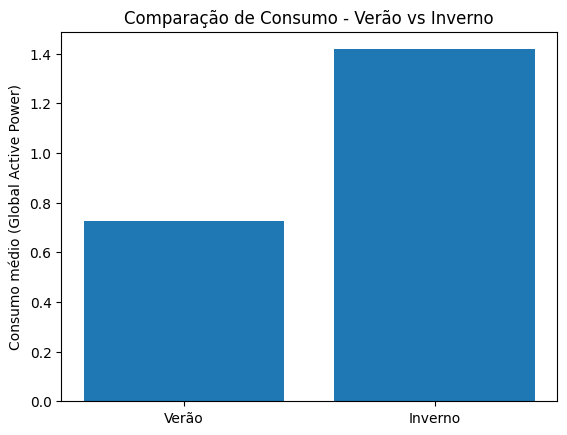

In [24]:
df_household["Month"] = df_household["Date"].dt.month
verao = df_household[df_household["Month"].isin([6, 7, 8])]
inverno = df_household[df_household["Month"].isin([12, 1, 2])]

consumo_verao = verao["Global_active_power"].mean()
consumo_inverno = inverno["Global_active_power"].mean()

plt.bar(["Verão", "Inverno"], [consumo_verao, consumo_inverno])
plt.ylabel("Consumo médio (Global Active Power)")
plt.title("Comparação de Consumo - Verão vs Inverno")
plt.show()

O consumo de energia no inverno é quase o dobro que no verão

--- 

### 16. Aplique uma amostragem aleatória de 1% dos dados e verifique se a distribuição deGlobal_active_power é semelhante à da base completa.

In [25]:
df_sample = df_household[['simple_date','Global_active_power']].sample(frac=0.01, random_state=42)

print(df_household[['simple_date','Global_active_power']].describe())
print(df_sample.describe())

       Global_active_power
count         2.049280e+06
mean          1.091615e+00
std           1.057294e+00
min           7.600000e-02
25%           3.080000e-01
50%           6.020000e-01
75%           1.528000e+00
max           1.112200e+01
       Global_active_power
count         20486.000000
mean              1.097499
std               1.049284
min               0.078000
25%               0.308000
50%               0.608000
75%               1.542000
max               7.878000


Esta semelhante, só não pegou na amostragem o maior valor da base completa
média, desvio padrão, e quartis estão similar ao dataset completo


--- 

### 17. Utilize uma técnica de normalização (Min-Max Scaling) para padronizar as variáveis numéricas principais.

#### 🔹 Como funciona (fórmula)

Essa técnica transforma os valores para um intervalo fixo (geralmente [0,1]).

$$
x' = \frac{x - x_{min}}{x_{max} - x_{min}}
$$

🔹 O que acontece:

Todos os valores vão ficar entre 0 e 1.

Você mantém o mesmo número de linhas e colunas, só muda a escala.

É ideal antes de algoritmos que dependem de distância (KNN, SVM, redes neurais, etc).

In [26]:
# Selecionando apenas as variáveis numéricas
df_numeric = df_household[[
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity"
]]

# Criando o scaler
scaler = MinMaxScaler()

# Aplicando transformação
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_numeric),
    columns=df_numeric.columns
)

df_scaled.head()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity
0,0.374796,0.300719,0.376090,0.377593
1,0.478363,0.313669,0.336995,0.473029
2,0.479631,0.358273,0.326010,0.473029
3,0.480898,0.361151,0.340549,0.473029
4,0.325005,0.379856,0.403231,0.323651


--- 

### 18. Aplique K-means para segmentar os dias em 3 grupos distintos de consumo elétrico. Interprete os resultados.

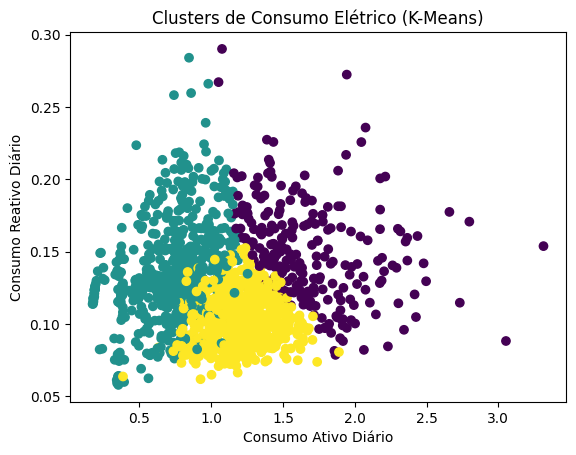

In [27]:
df_daily = (
    df_household.groupby("Date")
    .agg(
        {
            "Global_active_power": "mean",
            "Global_reactive_power": "mean",
            "Voltage": "mean",
            "Global_intensity": "mean",
        }
    )
    .reset_index()
)
df_daily = df_daily.dropna()

df_scaled = scaler.fit_transform(df_daily.drop(columns=["Date"]))

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_daily["Cluster"] = kmeans.fit_predict(df_scaled)

plt.scatter(
    df_daily["Global_active_power"],
    df_daily["Global_reactive_power"],
    c=df_daily["Cluster"],
    cmap="viridis",
)
plt.xlabel("Consumo Ativo Diário")
plt.ylabel("Consumo Reativo Diário")
plt.title("Clusters de Consumo Elétrico (K-Means)")
plt.show()

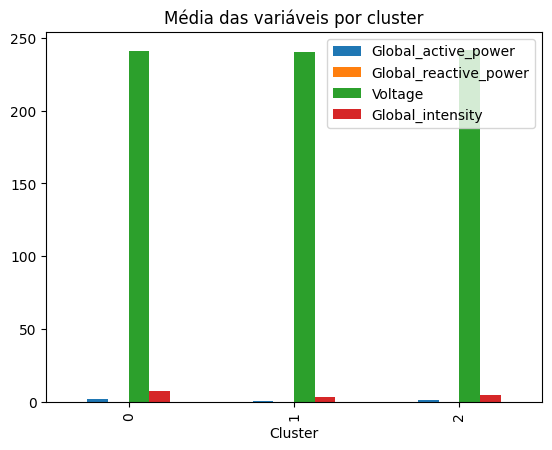

In [28]:
df_cluster_mean = df_daily.groupby("Cluster")[["Global_active_power", "Global_reactive_power", "Voltage", "Global_intensity"]].mean()
df_cluster_mean.plot(kind="bar")
plt.title("Média das variáveis por cluster")
plt.show()


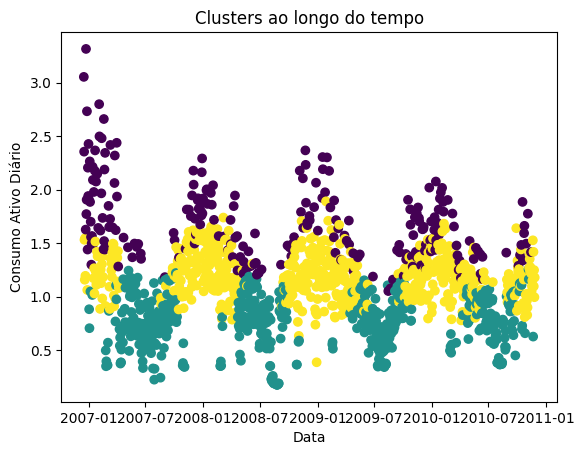

In [29]:
plt.scatter(df_daily["Date"], df_daily["Global_active_power"], c=df_daily["Cluster"], cmap="viridis")
plt.xlabel("Data")
plt.ylabel("Consumo Ativo Diário")
plt.title("Clusters ao longo do tempo")
plt.show()

calculou 3 centroides (pontos médios no espaço multidimensional).
Cada dia foi associado ao cluster mais próximo.

Tendo em vista que temos mais de uma 'coluna', podemos ter mais de uma visão:
1. Consumo ativo / Consumo reativo: 
    > não ajudou muito

2. como estão as medias das variáveis de forma categórica
3. onde se posicionam cada cluster de forma temporal 

Os clusters dividem o consumo de energia em:
- Alto
- Médio
- Baixo

--- 

### 19. Realize uma decomposição de série temporal (tendência, sazonalidade e resíduo) paraGlobal_active_power em um período de 6 meses.

<Figure size 1200x800 with 0 Axes>

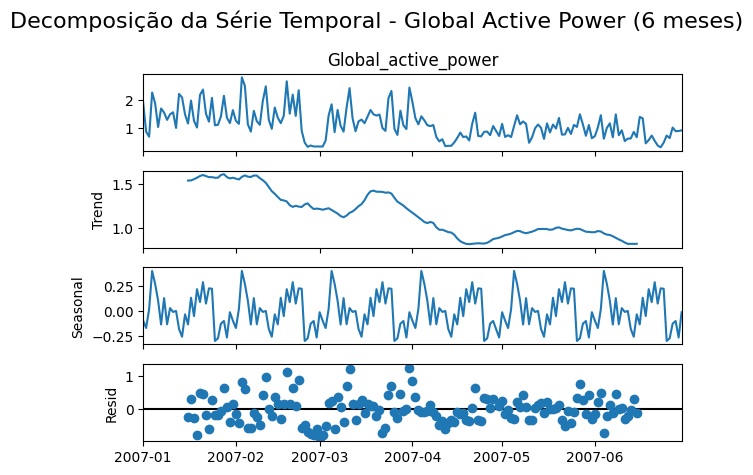

In [30]:
# Filtrar os 6 meses desejados
mask = (df_household["Date"] >= "2007-01-01") & (df_household["Date"] <= "2007-06-30")
df_6_months = df_household.loc[mask].copy()

# Fazer média diária para regularizar a frequência
df_daily = df_6_months.set_index("Date")["Global_active_power"].resample("D").mean()
df_daily = df_daily.dropna()

# Decomposição
decomposition = seasonal_decompose(df_daily, model="additive", period=30)  # 30 dias ~ 1 mês

# Plotar os componentes
plt.figure(figsize=(12, 8))
decomposition.plot()
plt.suptitle("Decomposição da Série Temporal - Global Active Power (6 meses)", fontsize=16)
plt.tight_layout()
plt.show()


1. **Série original (Global_active_power)**

- O primeiro gráfico é só a série bruta nos 6 meses.
- Ele mistura tendência, sazonalidade e ruído tudo junto.

2. **Tendência (Trend)**

- O segundo gráfico é a tendência de longo prazo.
  - Dá pra ver que em janeiro e fevereiro o consumo estava mais alto
  - Depois começou a cair a partir de março,
  - Em abril a junho se estabilizou em torno de 1.0 kW ou menos.

3. **Sazonalidade (Seasonal)**

- O terceiro gráfico mostra os padrões que se repetem regularmente.
- Parece haver um _ciclo quinzenal_ de picos.
- Isso indica que há um comportamento recorrente no consumo.

Existe um _padrão repetitivo de curto prazo_ que se mantém mesmo quando a tendência cai.

4. **Resíduo (Resid)**

- O quarto gráfico mostra aquilo que não é explicado nem pela tendência, nem pela sazonalidade.
- Basicamente, é o ruído aleatório: variações imprevisíveis, que podem vir de:

  - eventos esporádicos,
  - falhas de medição,
  - ou comportamentos não recorrentes.

- **Tendência:** mostra uma queda no consumo médio de energia ao longo dos 6 meses.
- **Sazonalidade:** revela padrões cíclicos quinzenais no consumo.
- **Resíduo:** representa as flutuações aleatórias que não seguem padrão fixo.

---

### 20. Treine um modelo de regressão linear simples para prever Global_active_power a partir de Global_intensity. Avalie o erro do modelo.


In [31]:
df_household = df_household.dropna()


In [32]:
df_household.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3', 'week_day', 'year', 'Total_Sub_metering',
       'simple_date', 'Month'],
      dtype='object')

In [33]:
df_global_intensity = df_household[["Global_intensity", "Global_active_power"]].copy()

train_set, test_set = train_test_split(df_global_intensity, test_size=0.2, random_state=42)
df_global_intensity_train = train_set.copy()
df_global_intensity_test = test_set.copy()

In [34]:

# Separar variáveis
X_train = df_global_intensity_train[["Global_intensity"]]  # <- colchetes duplos garantem 2D
y_train = df_global_intensity_train["Global_active_power"]

X_test = df_global_intensity_test[["Global_intensity"]]
y_test = df_global_intensity_test["Global_active_power"]

In [35]:
# Criar e treinar o modelo
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

print("Coeficiente angular (b):", lin_reg.coef_[0])
print("Coeficiente linear (a):", lin_reg.intercept_)

lin_reg

Coeficiente angular (b): 0.23762886427826596
Coeficiente linear (a): -0.008074949570015644


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [36]:
# Previsões
y_pred = lin_reg.predict(X_test)

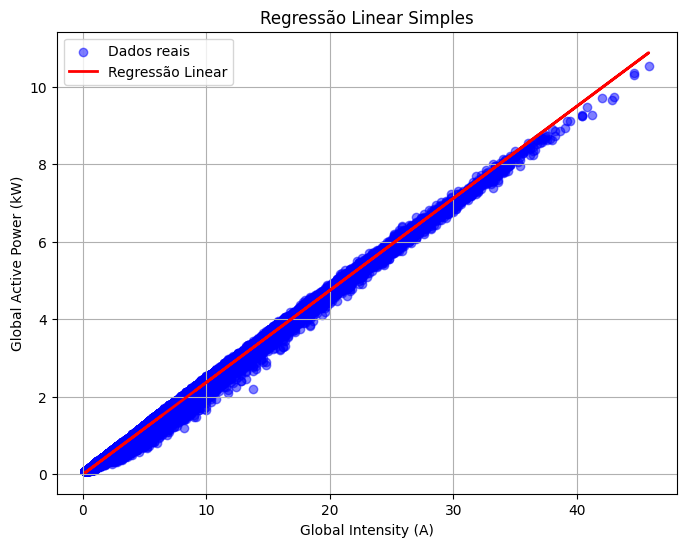

In [37]:
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, color="blue", alpha=0.5, label="Dados reais")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Regressão Linear")
plt.xlabel("Global Intensity (A)")
plt.ylabel("Global Active Power (kW)")
plt.title("Regressão Linear Simples")
plt.legend()
plt.grid(True)
plt.show()


In [38]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)


MSE: 0.002455557099982989
RMSE: 0.04955357807447398
R²: 0.9978152308016333


#### **R²**

- Mede o **quanto a reta explica a variabilidade dos dados** onde quanto mais perto de 1, melhor.

#### **MSE — Erro Quadrático Médio**

- Fórmula:

  $$
  MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
  $$

É a diferença entre o valor real (y) e o previsto pelo modelo (ŷ), eleva ao quadrado e faz a média.

- Quanto menor o MSE, melhor o modelo.
- Ele é sensível a outliers, porque o erro é elevado ao quadrado.
- Se quiser uma métrica mais na escala original, pode usar a raiz do MSE (**RMSE**):

$$
RMSE = \sqrt{MSE}
$$

---

### 21. Séries temporais por hora

- Converta Date e Time em índice datetime.
- Reamostre os dados em intervalos de 1 hora, calculando a média de Global_active_power.
- Identifique os horários de maior consumo médio ao longo do dia.Observação: uma série temporal é um conjunto de dados registrados em ordem cronológica, útil para identificar padrões de comportamento ao longo do tempo


In [39]:
hora_completa = df_household['Time'][2000]
hora_simples = hora_completa.split(':')[0]
hora_simples

df_household['hour'] = df_household['Time'].apply(lambda x: x.split(":")[0])
df_household.head()


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,week_day,year,Total_Sub_metering,simple_date,Month,hour
0,2006-12-16,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,Sabado,2006,18.0,2006-Dec,12,17
1,2006-12-16,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,Sabado,2006,17.0,2006-Dec,12,17
2,2006-12-16,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,Sabado,2006,19.0,2006-Dec,12,17
3,2006-12-16,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,Sabado,2006,18.0,2006-Dec,12,17
4,2006-12-16,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,Sabado,2006,18.0,2006-Dec,12,17


In [40]:
df_household.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3', 'week_day', 'year', 'Total_Sub_metering',
       'simple_date', 'Month', 'hour'],
      dtype='object')

In [41]:
df_grouped_hour = (
    df_household.groupby(["hour"])
    .agg(
        {
            "Global_active_power": "mean",
            "Global_reactive_power": "mean",
            "Voltage": "mean",
            "Global_intensity": "mean",
        }
    )
    .reset_index()
)
df_grouped_hour.head()

,hour,Global_active_power,Global_reactive_power,Voltage,Global_intensity
0,00,0.659434,0.114974,242.401809,2.806901
1,01,0.539325,0.104968,241.719412,2.312065
2,02,0.480621,0.105100,242.592898,2.064921
3,03,0.444866,0.103050,242.684657,1.917526
4,04,0.443847,0.099586,242.427262,1.911879


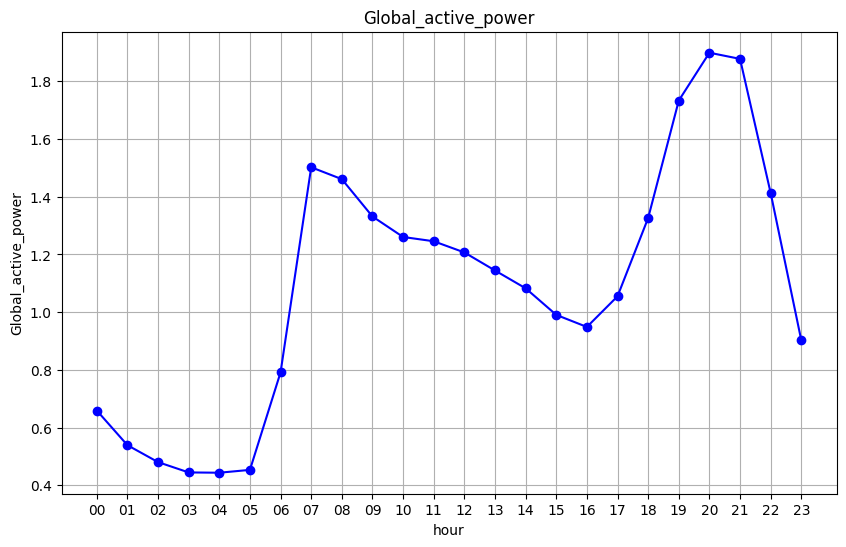

In [42]:
# Plotar a tendência de consumo ao longo dos anos
plt.figure(figsize=(10, 6))
plt.plot(
    df_grouped_hour["hour"],
    df_grouped_hour["Global_active_power"],
    marker="o",
    linestyle="-",
    color="b",
)
plt.xlabel("hour")
plt.ylabel("Global_active_power")
plt.title("Global_active_power")
plt.grid(True)
plt.show()

Temos 2 períodos de maior consumo 
1. pela manhã entre 7 e 8h
2. noite, entre 19 e 21h
> Consumo de energia durante a madrugada reduz drasticamente 

--- 

### 22. Autocorrelação do consumo. Use a série temporal de Global_active_power. Calcule a autocorrelação em lags de 1h, 24h e 48h. Pergunta: existem padrões repetidos diariamente?
Autocorrelação = “quanto a série se parece consigo mesma em diferentes deslocamentos no tempo (lags)”.


Autocorrelação com lag=1h: 0.713
Autocorrelação com lag=24h: 0.435
Autocorrelação com lag=48h: 0.399


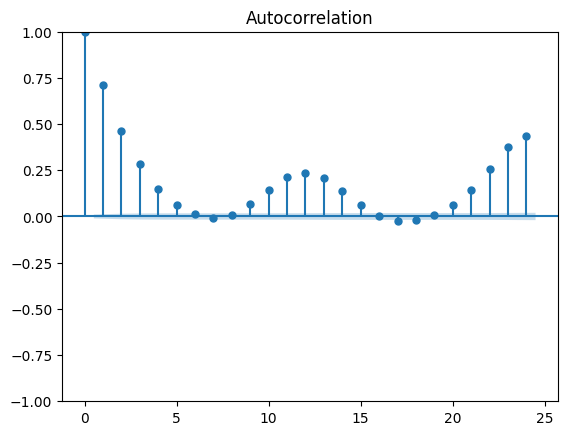

In [43]:
df_auto_corr_day = df_household[["Date", "Time", "Global_active_power"]].copy()

# Cria uma nova coluna datetime a partir de Date + Time
df_auto_corr_day["Datetime"] = pd.to_datetime(
    df_auto_corr_day["Date"].astype(str) + " " + df_auto_corr_day["Time"].astype(str),
    errors="coerce",
)

# Define como índice
df_auto_corr_day = df_auto_corr_day.set_index("Datetime").sort_index()

y = df_auto_corr_day["Global_active_power"].resample("h").mean()
y = y.dropna()

for lag in [1, 24, 48]:
    corr = y.autocorr(lag=lag)
    print(f"Autocorrelação com lag={lag}h: {corr:.3f}")

from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plot_acf(y.dropna(), lags=24)
plt.show()

Temos uma forte relação entre as horas, e podemos confirmar um padrão diário repetitivo.

---

### 23. Redução de dimensionalidade com PCA-Selecione Global_active_power, Global_reactive_power, Voltage e Global_intensity.-Aplique PCA para reduzir para 2 componentes principais.-Analise a variância explicada por cada componente.

In [44]:

# 1) Seleção das colunas
df_pca = df_household[[
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity"
]].copy().dropna()

# 2) Normalizar os dados (PCA é sensível à escala!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

# 3) Aplicar PCA com 2 componentes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4) Variância explicada
print("Variância explicada por cada componente:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"Componente {i+1}: {var:.2%}")

print("Variância total explicada:", pca.explained_variance_ratio_.sum())

# 5) Visualização (dados projetados em 2D)
# Variância explicada acumulada
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)


Variância explicada por cada componente:
Componente 1: 59.10%
Componente 2: 22.72%
Variância total explicada: 0.8182230176077273


**PCA**

1. **O que é**

   - Técnica de redução de dimensionalidade.
   - Cria novos eixos (**componentes principais**) a partir de combinações das variáveis originais.

2. **Ideia central**

   - Dados se espalham em certas direções.
   - O PCA encontra os **eixos onde há mais espalhamento (variância)**.
   - Cada novo eixo = um **componente principal (PC)**.

3. **Componentes**

   - **PC1** → direção que captura o máximo de variação.
   - **PC2** → direção ortogonal que captura a segunda maior variação.
   - E assim por diante.

4. **Variância explicada**

   - Mede quanta informação de todo o conjunto foi preservada no componente.
   - Exemplo: PC1 = 59%, PC2 = 23% → juntos = **82% da informação** dos 4 dados originais.

5. **Por que usar**

   - Reduz variáveis mantendo a maior parte da informação.
   - Remove redundância (quando variáveis são muito correlacionadas).
   - Facilita visualização (2D ou 3D).
   - Ajuda modelos de Machine Learning a rodarem mais rápido e com menos ruído.

---

### 24. Visualização de clusters no espaço PCA-Combine os resultados do PCA com K-Means (3 clusters). Plote os pontos resultantes e pinte cada grupo por cluster. Pergunta: os grupos se separam de forma clara?


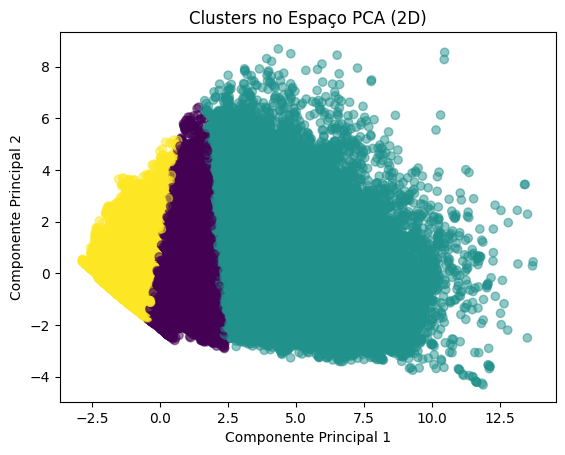

In [45]:
# 1) Selecionar e normalizar os dados
df_pca = df_household[[
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity"
]].copy().dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

# 2) PCA (2 componentes)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3) K-Means (3 clusters)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

# 4) Visualização
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap="viridis", alpha=0.5)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Clusters no Espaço PCA (2D)")
plt.show()

os clusters se separam de forma clara


--- 

### 25. Regressão polinomial vs linear; Modele Global_active_power em função de Voltage. Compare Regressão Linear Simples com Regressão Polinomial (grau 2). Analise RMSE e a curva ajustada

Coeficiente angular (b): -0.1304372485832542
Coeficiente linear (a): 32.506367321039086
MSE: 0.9446817839070233
RMSE: 0.9719474182830177
R²: 0.15949351625644748


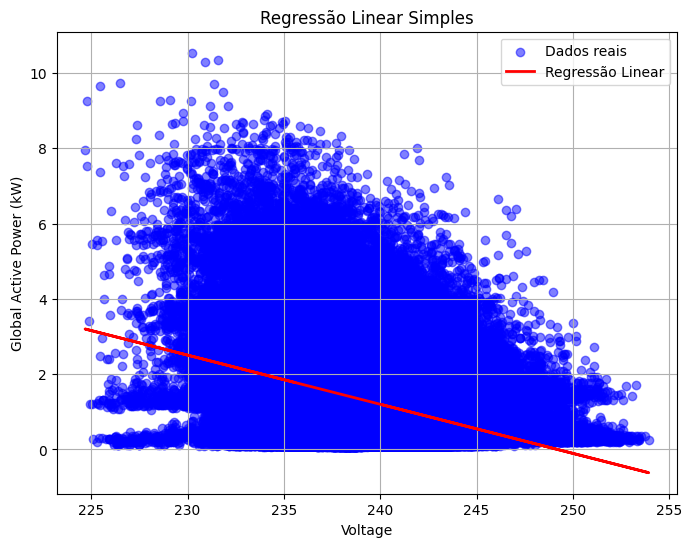

In [46]:
df_global_voltage = df_household[["Voltage", "Global_active_power"]].copy()

train_set, test_set = train_test_split(df_global_voltage, test_size=0.2, random_state=42)
df_global_voltage_train = train_set.copy()
df_global_voltage_test = test_set.copy()

# Separar variáveis
X_train = df_global_voltage_train[["Voltage"]]  
y_train = df_global_voltage_train["Global_active_power"]

X_test = df_global_voltage_test[["Voltage"]]
y_test = df_global_voltage_test["Global_active_power"]

# Criar e treinar o modelo
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

print("Coeficiente angular (b):", lin_reg.coef_[0])
print("Coeficiente linear (a):", lin_reg.intercept_)

# Previsões
y_pred = lin_reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, color="blue", alpha=0.5, label="Dados reais")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Regressão Linear")
plt.xlabel("Voltage")
plt.ylabel("Global Active Power (kW)")
plt.title("Regressão Linear Simples")
plt.legend()
plt.grid(True)
plt.show()

Polinomial -> RMSE=0.9674, R²=0.1673
Equação: y = 341.766137 + (-2.704754)*V + (0.005356)*V^2


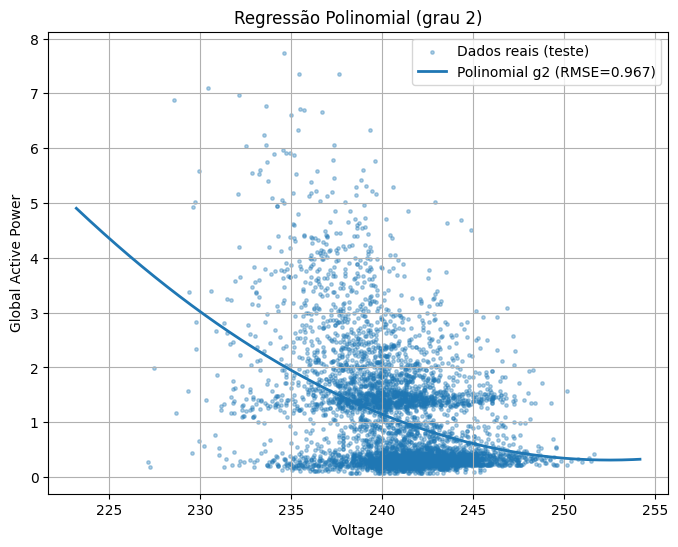

In [47]:
# ===== 1) Dados (ajuste os nomes se precisar) =====
df_reg = df_household[["Voltage", "Global_active_power"]].dropna().copy()
X = df_reg[["Voltage"]].values
y = df_reg["Global_active_power"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===== 2) Modelo Polinomial (grau 2) =====
poly = PolynomialFeatures(degree=2, include_bias=False) 
X_train_poly = poly.fit_transform(X_train)
X_test_poly  = poly.transform(X_test)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)

y_pred_poly = poly_reg.predict(X_test_poly)

# Métricas (RMSE e R² no TESTE)
mse = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse)
r2_poly   = r2_score(y_test, y_pred_poly)

print(f"Polinomial -> RMSE={rmse_poly:.4f}, R²={r2_poly:.4f}")

# ===== 3) Equação do modelo =====
# y = a + b1*V + b2*V^2
a  = poly_reg.intercept_
b1, b2 = poly_reg.coef_
print(f"Equação: y = {a:.6f} + ({b1:.6f})*V + ({b2:.6f})*V^2")

# ===== 4) Curva suave para plot =====
# Faixa ordenada para desenhar a curva
V_min, V_max = X.min(), X.max()
X_range = np.linspace(V_min, V_max, 500).reshape(-1, 1)
X_range_poly = poly.transform(X_range)
y_range_poly = poly_reg.predict(X_range_poly)

# amostrar pontos para o scatter se tiver muito dado
idx_plot = np.random.choice(len(X_test), size=min(5000, len(X_test)), replace=False)
 
plt.figure(figsize=(8,6))
plt.scatter(X_test[idx_plot], y_test[idx_plot], s=6, alpha=0.35, label="Dados reais (teste)")
plt.plot(X_range, y_range_poly, linewidth=2, label=f"Polinomial g2 (RMSE={rmse_poly:.3f})")
plt.xlabel("Voltage")
plt.ylabel("Global Active Power")
plt.title("Regressão Polinomial (grau 2)")
plt.legend()
plt.grid(True)
plt.show()


Tanto a regressão linear simples quanto a regressão polinomial mostraram que não há relação significativa entre a tensão e o consumo de energia

---

### 